# Daily Challenge: Breast Cancer Prediction



In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Path to dataset files: /kaggle/input/breast-cancer-wisconsin-data


In [2]:
# 1️ Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

In [4]:
# 2️ Load dataset (correct path in Colab Kaggle cache)
df = pd.read_csv("/kaggle/input/breast-cancer-wisconsin-data/data.csv")
print("First 5 rows:")
display(df.head())

First 5 rows:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



Missing values per column:
 id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_di

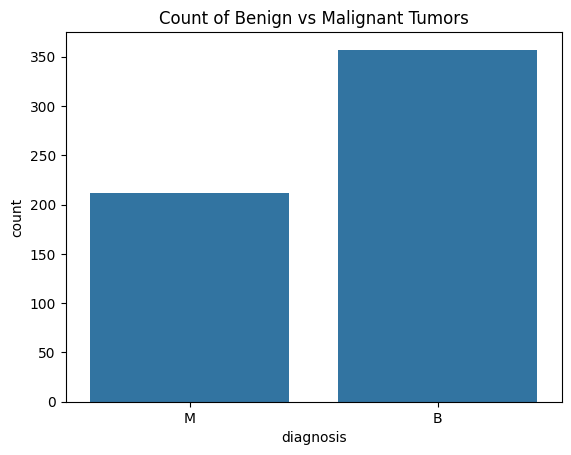


Diagnosis value counts:
 diagnosis
B    357
M    212
Name: count, dtype: int64


In [5]:
# 3️ EDA
print("\nMissing values per column:\n", df.isnull().sum())
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')  # drop unnecessary columns

sns.countplot(x='diagnosis', data=df)
plt.title("Count of Benign vs Malignant Tumors")
plt.show()

print("\nDiagnosis value counts:\n", df['diagnosis'].value_counts())


In [6]:
# 4️ Preprocessing
df['diagnosis'] = df['diagnosis'].map({'B':0, 'M':1})  # map to numeric
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Feature scaling (important for KNN & SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [7]:
# 5️ Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)



In [8]:
# 6️ Build models
# Logistic Regression
lr = LogisticRegression(max_iter=10000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# SVM
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)



In [9]:
# 7️ Compare models
models = {
    'Logistic Regression': accuracy_score(y_test, y_pred_lr),
    'KNN': accuracy_score(y_test, y_pred_knn),
    'Random Forest': accuracy_score(y_test, y_pred_rf),
    'SVM': accuracy_score(y_test, y_pred_svm)
}

best_model = max(models, key=models.get)

print("\nModel Accuracies:")
for m, acc in models.items():
    print(f"{m}: {acc:.4f}")

print(f"\nBest Model: {best_model} with accuracy: {models[best_model]:.4f}")




Model Accuracies:
Logistic Regression: 0.9737
KNN: 0.9474
Random Forest: 0.9649
SVM: 0.9561

Best Model: Logistic Regression with accuracy: 0.9737


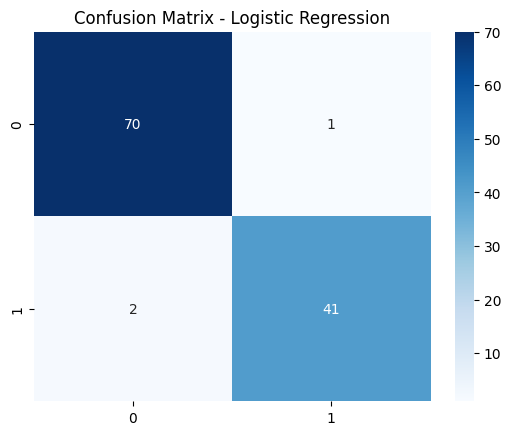

In [10]:
# 8 Confusion matrix for best model
best_pred = {'Logistic Regression': y_pred_lr,
             'KNN': y_pred_knn,
             'Random Forest': y_pred_rf,
             'SVM': y_pred_svm}[best_model]

sns.heatmap(confusion_matrix(y_test, best_pred), annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model}')
plt.show()